In [1]:
!git clone https://github.com/FaisalTahair/heart_disease_ml_model.git


Cloning into 'heart_disease_ml_model'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [2]:
%cd heart_disease_ml_model


/content/heart_disease_ml_model


In [5]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve,auc,ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

import warnings
warnings.filterwarnings('ignore')


In [7]:
file_path = "/content/drive/MyDrive/dataset.csv"
df = pd.read_csv(file_path)

# Basic information
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (1190, 12)

First 5 rows:
   age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0   40    1                2           140          289                    0   
1   49    0                3           160          180                    0   
2   37    1                2           130          283                    0   
3   48    0                4           138          214                    0   
4   54    1                3           150          195                    0   

   resting ecg  max heart rate  exercise angina  oldpeak  ST slope  target  
0            0             172                0      0.0         1       0  
1            0             156                0      1.0         2       1  
2            1              98                0      0.0         1       0  
3            0             108                1      1.5         2       1  
4            0             122                0      0.0         1       0  

Missing values 

In [8]:
print("Target class distribution:\n", df['target'].value_counts(normalize=True))


Target class distribution:
 target
1    0.528571
0    0.471429
Name: proportion, dtype: float64


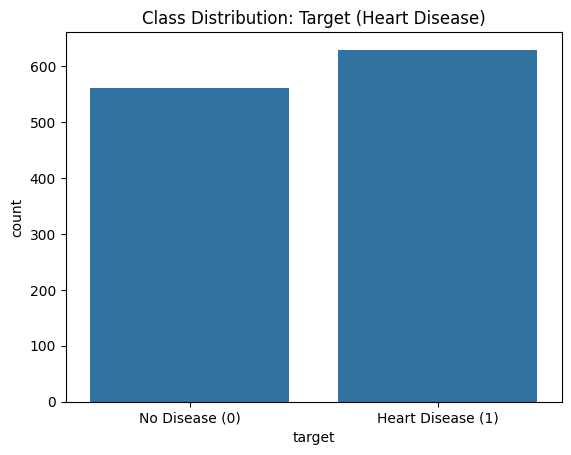


Dataset shape after encoding: (1190, 17)
Encoded columns:
 Index(['age', 'sex', 'resting bp s', 'cholesterol', 'fasting blood sugar',
       'max heart rate', 'exercise angina', 'oldpeak', 'target',
       'chest pain type_2', 'chest pain type_3', 'chest pain type_4',
       'resting ecg_1', 'resting ecg_2', 'ST slope_1', 'ST slope_2',
       'ST slope_3'],
      dtype='object')


In [9]:
sns.countplot(x='target', data=df)
plt.title("Class Distribution: Target (Heart Disease)")
plt.xticks([0, 1], ['No Disease (0)', 'Heart Disease (1)'])
plt.show()

# 3. One-hot encode nominal categorical variables
nominal_features = ['chest pain type', 'resting ecg', 'ST slope']
df_encoded = pd.get_dummies(df, columns=nominal_features, drop_first=True)

print("\nDataset shape after encoding:", df_encoded.shape)
print("Encoded columns:\n", df_encoded.columns)

In [10]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training samples: 952
Testing samples: 238


COMPARISON BETWEEN DIFFERENT MODELS

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-Score": report["1"]["f1-score"]
    }

results_df = pd.DataFrame(results).T
print(results_df.sort_values(by="F1-Score", ascending=False))


                     Accuracy  Precision    Recall  F1-Score
Random Forest        0.907563   0.933333  0.888889  0.910569
Decision Tree        0.882353   0.915254  0.857143  0.885246
Logistic Regression  0.861345   0.854962  0.888889  0.871595
SVM                  0.731092   0.758333  0.722222  0.739837
KNN                  0.701681   0.700730  0.761905  0.730038


In [12]:
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

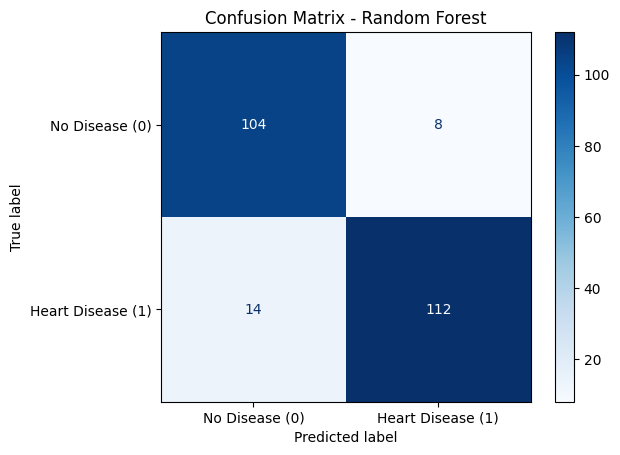

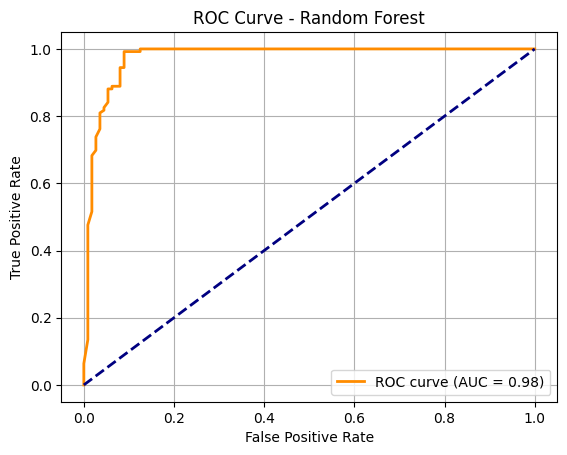

In [13]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease (0)", "Heart Disease (1)"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()


fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


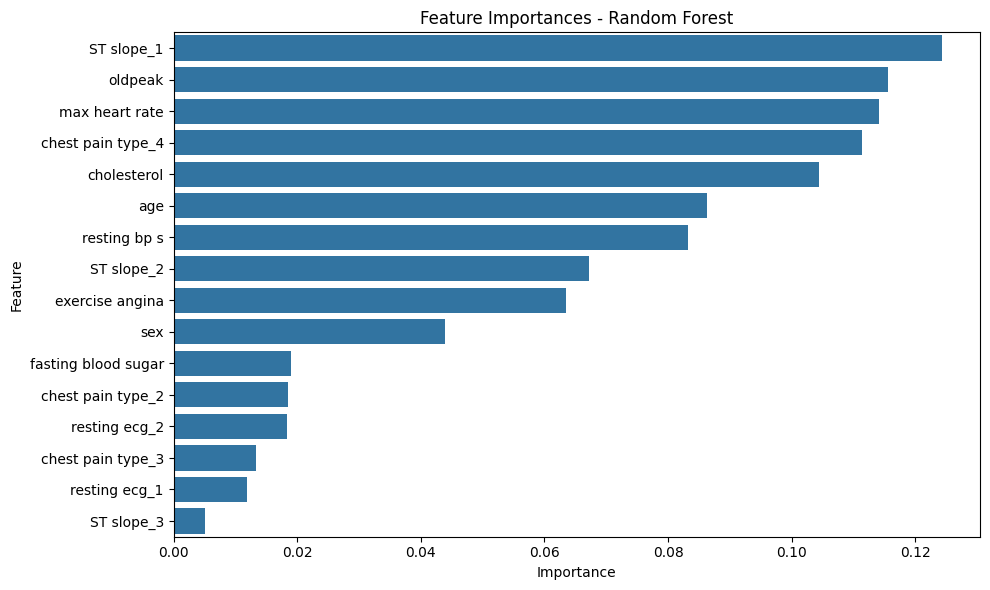

In [14]:
importances = rf_model.feature_importances_
features = X_train.columns

feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances - Random Forest')
plt.tight_layout()
plt.show()


HYPERPARAMETER TUNING

In [15]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Accuracy: 0.9075998897767981


RETRAIN MODEL WITH ABOVE PARAMETERS:

In [16]:
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

best_rf.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

In [17]:
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]  # For ROC AUC


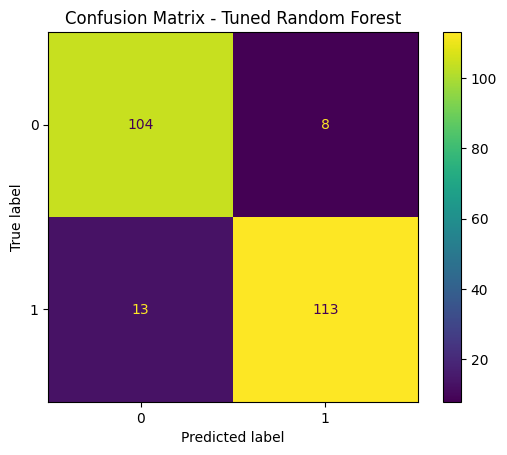

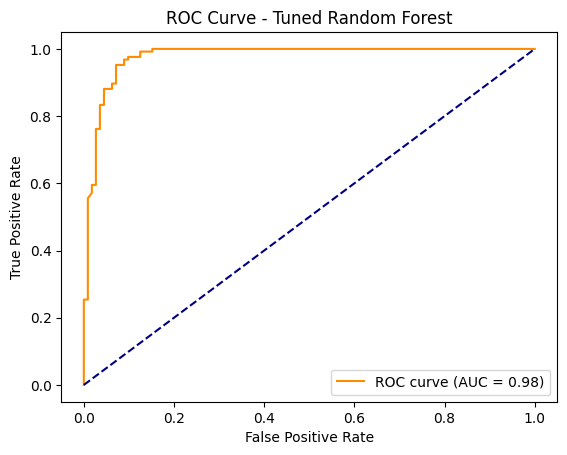

In [18]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend(loc="lower right")
plt.show()


In [19]:
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       112
           1       0.93      0.90      0.91       126

    accuracy                           0.91       238
   macro avg       0.91      0.91      0.91       238
weighted avg       0.91      0.91      0.91       238



In [20]:
sample = X_test.iloc[0]
prediction = best_rf.predict([sample])
probability = best_rf.predict_proba([sample])

if prediction[0] == 1:
    print(" High Risk: The model predicts a strong chance of heart disease.")
else:
    print(" Low Risk: The model predicts no major sign of heart disease.")

print(f"Prediction Confidence: {probability[0][prediction[0]] * 100:.2f}%")



 High Risk: The model predicts a strong chance of heart disease.
Prediction Confidence: 98.00%


SAVING CONFIGURATIONS

In [23]:
joblib.dump(best_rf, '/content/drive/MyDrive/heart_disease_ML.pkl')

['/content/drive/MyDrive/heart_disease_ML.pkl']

In [24]:
!git config --global user.name "FaisalTahair"
!git config --global user.email "faisal.wrkggl@gmail.com"



In [26]:
!cp "/content/drive/MyDrive/heart_disease_ML.pkl" .


In [30]:
!git clone https://github.com/FaisalTahair/heart_disease_ml_model.git


Cloning into 'heart_disease_ml_model'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [36]:
import os

# This will list all files in your current directory
os.listdir()


['.git', 'README.md', 'heart_disease_ml_model']

In [34]:
!mv heart_disease_ML.pkl heart_disease_ml_model/
!mv Heart_disease.ipynb heart_disease_ml_model/


mv: cannot stat 'Heart_disease.ipynb': No such file or directory
